# Felicidade do Cliente na Olist: o que faz um cliente virar promotor ou detrator?

**Base:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle) — cerca de 100 mil pedidos feitos entre setembro/2016 e agosto/2018 em marketplaces parceiros da Olist no Brasil.

**Pergunta que este notebook responde:** o que realmente move a satisfação do cliente nesse e-commerce — prazo de entrega, categoria de produto, região, forma de pagamento? E o que os clientes insatisfeitos estão dizendo com as próprias palavras?

**Como os dados chegam aqui:** este notebook consome o esquema estrela gerado por [`src/etl_pipeline.py`](../src/etl_pipeline.py) (rode esse script antes, se estiver clonando o repositório). Duas decisões de modelagem tomadas ali afetam todos os números deste notebook:

1. **Grão do `fato_pedidos` = 1 linha por pedido avaliado.** Uma versão anterior deste pipeline cruzava reviews com itens do pedido usando só `order_id`; pedidos com mais de um item duplicavam a linha da review. Isso foi corrigido (há um `assert` no próprio script garantindo 1:1).
2. **Usamos todas as ~98,7 mil avaliações com nota**, não só as ~41 mil que também têm comentário de texto — senão descartaríamos mais da metade da amostra de satisfação.

> **Nota de nomenclatura:** chamamos a classificação de Promotor/Neutro/Detrator de **"faixa de satisfação"**, não de "NPS". A Olist não faz a pergunta clássica de NPS ("o quão provável você recomendaria..."); o que temos é satisfação derivada da nota de 1 a 5 dada ao pedido.

In [1]:
import os
import re
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath('../src'))
from viz_theme import (
    CATEGORICO_ORDEM, COR_ATRASADO, COR_ADIANTADO, COR_DETRATOR, COR_NEUTRO,
    COR_PROMOTOR, CORES_SATISFACAO, GRADE, ORDEM_SATISFACAO, SEQUENCIAL_AZUL,
    TINTA_MUTED, TINTA_SECUNDARIA, aplicar_estilo_matplotlib,
)

aplicar_estilo_matplotlib()

DIR_PROCESSED = '../data/processed'
DIR_IMG = '../assets/img'
os.makedirs(DIR_IMG, exist_ok=True)


def salvar(fig, nome):
    """Salva a figura em assets/img/ (usada depois no README e no post)."""
    fig.savefig(os.path.join(DIR_IMG, nome), bbox_inches='tight')


fato_pedidos = pd.read_csv(
    os.path.join(DIR_PROCESSED, 'fato_pedidos.csv'),
    parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
)
dim_clientes = pd.read_csv(os.path.join(DIR_PROCESSED, 'dim_clientes.csv'))

fato_pedidos = fato_pedidos.merge(dim_clientes[['customer_id', 'customer_state']], on='customer_id', how='left')

print(f'{len(fato_pedidos):,} pedidos avaliados carregados | {fato_pedidos["order_id"].nunique():,} order_id únicos')

98,673 pedidos avaliados carregados | 98,673 order_id únicos


## 1. Panorama geral

Antes de procurar drivers, o básico: como as notas se distribuem, e quantos clientes caem em cada faixa de satisfação.

,indicador,valor
0,Nota média (1-5),4.09
1,% Detrator,14.70
2,% Neutro,8.20
3,% Promotor,77.10
4,% entregas no prazo,93.30
5,Tempo médio de entrega (dias),12.10
6,Ticket médio (R$),160.34


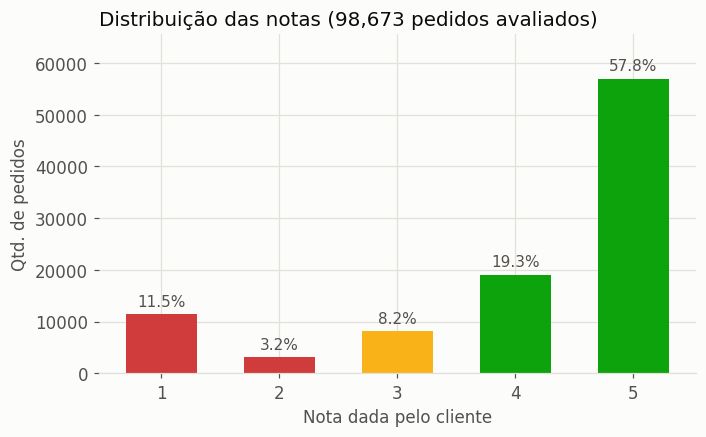

In [2]:
total_pedidos = len(fato_pedidos)
nota_media = fato_pedidos['review_score'].mean()
pct_satisfacao = (fato_pedidos['faixa_satisfacao'].value_counts(normalize=True) * 100).reindex(ORDEM_SATISFACAO)
taxa_no_prazo = fato_pedidos['entrega_no_prazo'].astype('boolean').mean() * 100
dias_entrega_medio = fato_pedidos['dias_entrega'].mean()
ticket_medio = fato_pedidos['valor_total_pedido'].mean()

kpis = pd.DataFrame({
    'indicador': [
        'Nota média (1-5)', '% Detrator', '% Neutro', '% Promotor',
        '% entregas no prazo', 'Tempo médio de entrega (dias)', 'Ticket médio (R$)',
    ],
    'valor': [
        round(nota_media, 2), round(pct_satisfacao['Detrator'], 1), round(pct_satisfacao['Neutro'], 1),
        round(pct_satisfacao['Promotor'], 1), round(taxa_no_prazo, 1), round(dias_entrega_medio, 1),
        round(ticket_medio, 2),
    ],
})
display(kpis)

# --- Gráfico: distribuição das notas, coloridas pela faixa de satisfação ---
cor_por_nota = {1: COR_DETRATOR, 2: COR_DETRATOR, 3: COR_NEUTRO, 4: COR_PROMOTOR, 5: COR_PROMOTOR}
contagem_notas = fato_pedidos['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    contagem_notas.index, contagem_notas.values,
    color=[cor_por_nota[n] for n in contagem_notas.index], width=0.6,
)
for barra, valor in zip(barras, contagem_notas.values):
    pct = valor / total_pedidos * 100
    ax.text(
        barra.get_x() + barra.get_width() / 2, valor + total_pedidos * 0.01,
        f'{pct:.1f}%', ha='center', va='bottom', color=TINTA_SECUNDARIA, fontsize=10,
    )
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel('Nota dada pelo cliente')
ax.set_ylabel('Qtd. de pedidos')
ax.set_title(f'Distribuição das notas ({total_pedidos:,} pedidos avaliados)', loc='left', fontsize=13)
ax.set_ylim(0, contagem_notas.max() * 1.15)
salvar(fig, '01_distribuicao_notas.png')
plt.show()

## 2. O maior driver: prazo de entrega

A Olist mostra ao cliente uma data estimada de entrega no momento da compra. A hipótese óbvia: quem recebe depois dessa data fica mais insatisfeito. Vale testar com números.

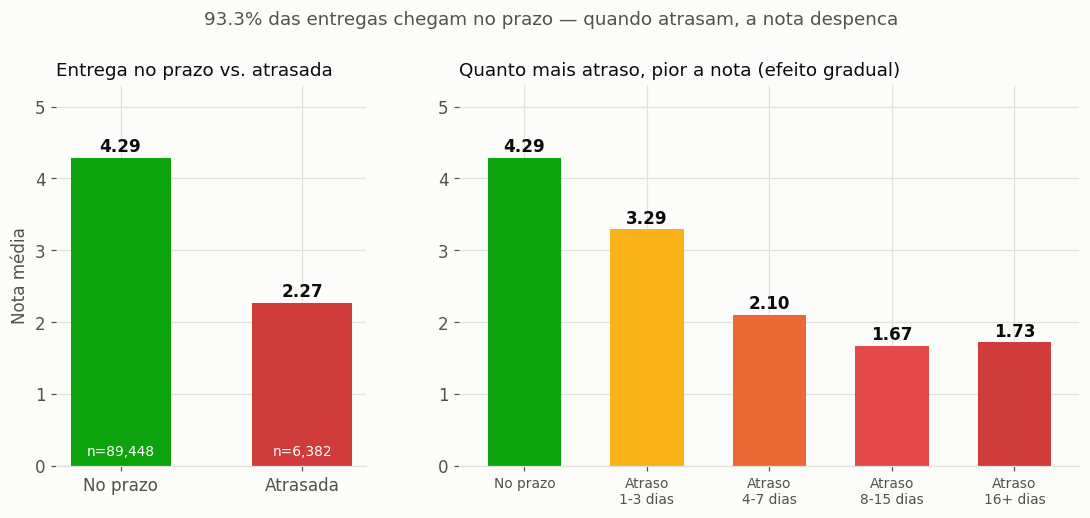

Correlação (atraso em dias x nota): -0.267


In [3]:
entregues = fato_pedidos.dropna(subset=['entrega_no_prazo']).copy()
entregues['entrega_no_prazo'] = entregues['entrega_no_prazo'].astype('boolean')

# reindex([True, False]) explicito: o groupby ordena por valor booleano
# (False antes de True) e isso não bate com a ordem em que os rótulos
# 'No prazo'/'Atrasada' são desenhados a seguir — sem o reindex, a barra
# errada recebe a cor e o rótulo errados.
resumo_prazo = entregues.groupby('entrega_no_prazo', observed=True)['review_score'].agg(['mean', 'count'])
resumo_prazo = resumo_prazo.reindex([True, False])
resumo_prazo.index = ['No prazo', 'Atrasada']

# faixas de atraso, para mostrar o efeito "dose-resposta"
bins = [-9999, 0, 3, 7, 15, 9999]
labels = ['No prazo', 'Atraso\n1-3 dias', 'Atraso\n4-7 dias', 'Atraso\n8-15 dias', 'Atraso\n16+ dias']
entregues['faixa_atraso'] = pd.cut(entregues['atraso_dias'], bins=bins, labels=labels)
cores_faixa_atraso = {
    'No prazo': COR_PROMOTOR, 'Atraso\n1-3 dias': COR_NEUTRO, 'Atraso\n4-7 dias': '#eb6834',
    'Atraso\n8-15 dias': COR_ATRASADO, 'Atraso\n16+ dias': COR_DETRATOR,
}
resumo_atraso = entregues.groupby('faixa_atraso', observed=True)['review_score'].agg(['mean', 'count']).loc[labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), width_ratios=[1, 2])

# Painel 1: no prazo x atrasado
cores1 = [COR_PROMOTOR, COR_DETRATOR]
barras1 = ax1.bar(resumo_prazo.index, resumo_prazo['mean'], color=cores1, width=0.55)
for barra, (media, n) in zip(barras1, resumo_prazo[['mean', 'count']].values):
    ax1.text(barra.get_x() + barra.get_width() / 2, media + 0.08, f'{media:.2f}', ha='center', fontweight='bold')
    ax1.text(barra.get_x() + barra.get_width() / 2, 0.15, f'n={int(n):,}', ha='center', color='white', fontsize=9)
ax1.set_ylim(0, 5.3)
ax1.set_ylabel('Nota média')
ax1.set_title('Entrega no prazo vs. atrasada', loc='left', fontsize=12)

# Painel 2: efeito dose-resposta por faixa de atraso
barras2 = ax2.bar(labels, resumo_atraso['mean'], color=[cores_faixa_atraso[l] for l in labels], width=0.6)
for barra, media in zip(barras2, resumo_atraso['mean']):
    ax2.text(barra.get_x() + barra.get_width() / 2, media + 0.08, f'{media:.2f}', ha='center', fontweight='bold')
ax2.set_ylim(0, 5.3)
ax2.set_title('Quanto mais atraso, pior a nota (efeito gradual)', loc='left', fontsize=12)
ax2.tick_params(axis='x', labelsize=9)

fig.suptitle(f'{taxa_no_prazo:.1f}% das entregas chegam no prazo — quando atrasam, a nota despenca', y=1.03, fontsize=12, color=TINTA_SECUNDARIA)
salvar(fig, '02_prazo_de_entrega.png')
plt.show()

print(f"Correlação (atraso em dias x nota): {entregues['atraso_dias'].corr(entregues['review_score']):.3f}")

**Achado:** entregas atrasadas caem de uma nota média de ~4,3 para ~2,3 — uma queda de quase 2 pontos em uma escala de 5. E o efeito é gradual: cada faixa adicional de atraso piora a nota um pouco mais, não é um salto único. Isso é o oposto de um problema pontual — é o driver mais forte de insatisfação nesta base, e afeta uma fração pequena mas ruidosa dos pedidos.

## 3. Satisfação por categoria de produto

Nem todo produto gera a mesma experiência. Comparamos a nota média por categoria (usando a categoria do item de maior valor de cada pedido), olhando só categorias com pelo menos 30 pedidos avaliados para não deixar uma categoria pequena parecer melhor ou pior do que é por acaso.

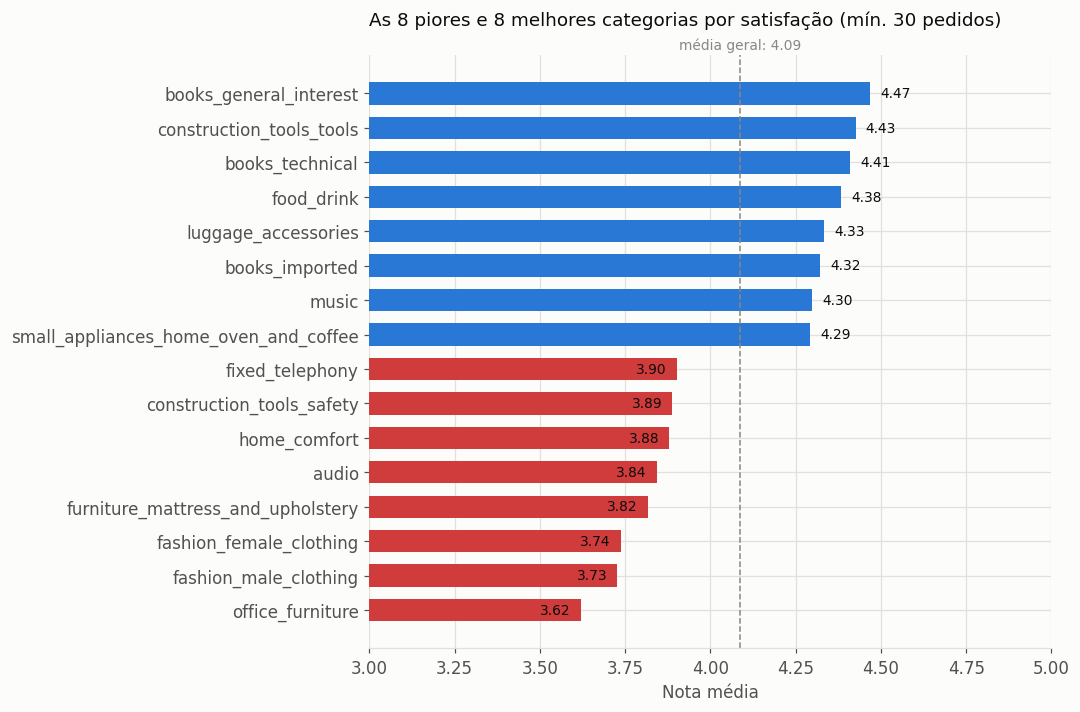

63 categorias com pelo menos 30 pedidos avaliados.


In [4]:
N_MIN_CATEGORIA = 30
resumo_categoria = fato_pedidos.groupby('categoria_produto_principal').agg(
    nota_media=('review_score', 'mean'), qtd=('order_id', 'count'),
)
resumo_categoria = resumo_categoria[resumo_categoria['qtd'] >= N_MIN_CATEGORIA].sort_values('nota_media')

piores8 = resumo_categoria.head(8)
melhores8 = resumo_categoria.tail(8)
extremos = pd.concat([piores8, melhores8]).reset_index()

fig, ax = plt.subplots(figsize=(8, 7))
cores = [COR_DETRATOR if v < nota_media else CATEGORICO_ORDEM[0] for v in extremos['nota_media']]
ax.barh(extremos['categoria_produto_principal'], extremos['nota_media'], color=cores, height=0.65)
for i, (cat, v) in enumerate(zip(extremos['categoria_produto_principal'], extremos['nota_media'])):
    ax.text(v + 0.03 if v >= nota_media else v - 0.03, i, f'{v:.2f}',
            va='center', ha='left' if v >= nota_media else 'right', fontsize=9)

ax.axvline(nota_media, color=TINTA_MUTED, linestyle='--', linewidth=1)
# eixo y em coordenada de dados, mas y em fração dos eixos (0-1): assim o
# rótulo sempre fica logo acima da última barra, sem colidir com o título
# nem depender de quantas barras existem
ax.text(nota_media, 1.01, f'média geral: {nota_media:.2f}', color=TINTA_MUTED, fontsize=9, ha='center',
        transform=ax.get_xaxis_transform())
ax.set_xlim(3.0, 5.0)
ax.set_xlabel('Nota média')
ax.set_title(f'As 8 piores e 8 melhores categorias por satisfação (mín. {N_MIN_CATEGORIA} pedidos)', loc='left', fontsize=12, pad=20)
salvar(fig, '03_categorias_produto.png')
plt.show()

print(f'{len(resumo_categoria)} categorias com pelo menos {N_MIN_CATEGORIA} pedidos avaliados.')

**Achado:** `office_furniture` (móveis de escritório) é a categoria com pior nota entre as que têm volume relevante (3,62, com 1.260 pedidos — não é ruído de amostra pequena). Categorias de livros (`books_general_interest`, `books_technical`) e `food_drink` ficam no topo. Um padrão comum em e-commerce: itens grandes/frágeis (móveis) sofrem mais com avarias e problemas logísticos do que itens pequenos e previsíveis (livros).

## 4. Satisfação por região

O Brasil é grande e a malha logística não é uniforme. Comparamos a nota média por estado do cliente.

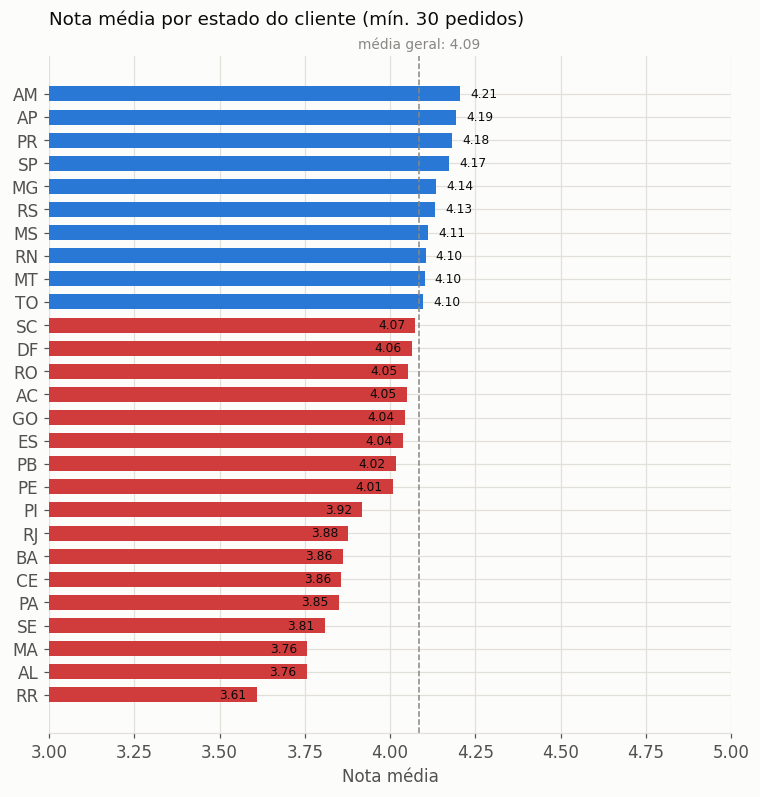

In [5]:
resumo_estado = fato_pedidos.groupby('customer_state').agg(
    nota_media=('review_score', 'mean'), qtd=('order_id', 'count'),
).sort_values('nota_media')
excluidos = resumo_estado[resumo_estado['qtd'] < N_MIN_CATEGORIA]
resumo_estado = resumo_estado[resumo_estado['qtd'] >= N_MIN_CATEGORIA]

fig, ax = plt.subplots(figsize=(8, 8))
cores = [COR_DETRATOR if v < nota_media else CATEGORICO_ORDEM[0] for v in resumo_estado['nota_media']]
ax.barh(resumo_estado.index, resumo_estado['nota_media'], color=cores, height=0.65)
for i, v in enumerate(resumo_estado['nota_media']):
    ax.text(v + 0.03 if v >= nota_media else v - 0.03, i, f'{v:.2f}',
            va='center', ha='left' if v >= nota_media else 'right', fontsize=8)

ax.axvline(nota_media, color=TINTA_MUTED, linestyle='--', linewidth=1)
ax.text(nota_media, 1.01, f'média geral: {nota_media:.2f}', color=TINTA_MUTED, fontsize=9, ha='center',
        transform=ax.get_xaxis_transform())
ax.set_xlim(3.0, 5.0)
ax.set_xlabel('Nota média')
ax.set_title(f'Nota média por estado do cliente (mín. {N_MIN_CATEGORIA} pedidos)', loc='left', fontsize=12, pad=20)
salvar(fig, '04_satisfacao_por_estado.png')
plt.show()

if len(excluidos):
    print(f'Estados com menos de {N_MIN_CATEGORIA} pedidos (fora do gráfico): {", ".join(excluidos.index)}')

**Achado:** os estados com pior nota média (RR, AL, MA) são justamente estados do Norte/Nordeste mais distantes dos grandes centros de distribuição (concentrados no Sudeste/Sul). Isso é consistente com o driver da seção 2 — mais distância tende a significar mais risco de atraso. Vale cruzar `atraso_dias` por estado no dashboard para confirmar se é exatamente esse o mecanismo.

## 5. Forma de pagamento e parcelamento

Será que como o cliente paga também tem relação com a satisfação?

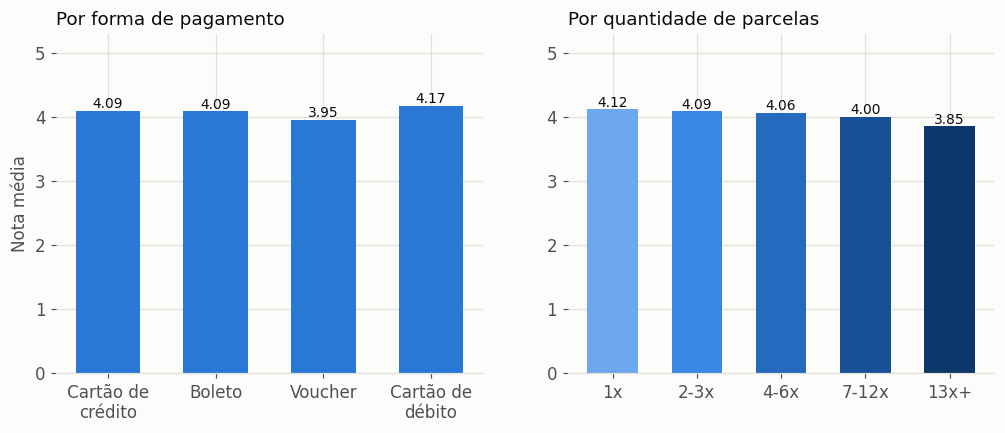

In [6]:
TRADUCAO_PAGAMENTO = {
    'credit_card': 'Cartão de\ncrédito', 'boleto': 'Boleto', 'voucher': 'Voucher',
    'debit_card': 'Cartão de\ndébito', 'not_defined': 'Não\ndefinido',
}
resumo_pagamento = fato_pedidos.groupby('forma_pagamento_principal').agg(
    nota_media=('review_score', 'mean'), qtd=('order_id', 'count'),
)
resumo_pagamento = resumo_pagamento[resumo_pagamento['qtd'] >= N_MIN_CATEGORIA].sort_values('qtd', ascending=False)
resumo_pagamento.index = resumo_pagamento.index.map(TRADUCAO_PAGAMENTO)

fato_pedidos['faixa_parcelas'] = pd.cut(
    fato_pedidos['parcelas_pagamento_principal'], bins=[-1, 1, 3, 6, 12, 99],
    labels=['1x', '2-3x', '4-6x', '7-12x', '13x+'],
)
resumo_parcelas = fato_pedidos.groupby('faixa_parcelas', observed=True)['review_score'].agg(['mean', 'count'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(resumo_pagamento.index, resumo_pagamento['nota_media'], color=CATEGORICO_ORDEM[0], width=0.6)
for i, v in enumerate(resumo_pagamento['nota_media']):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
ax1.set_ylim(0, 5.3)
ax1.set_ylabel('Nota média')
ax1.set_title('Por forma de pagamento', loc='left', fontsize=12)

ax2.bar(resumo_parcelas.index.astype(str), resumo_parcelas['mean'], color=SEQUENCIAL_AZUL[2:7], width=0.6)
for i, v in enumerate(resumo_parcelas['mean']):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
ax2.set_ylim(0, 5.3)
ax2.set_title('Por quantidade de parcelas', loc='left', fontsize=12)

salvar(fig, '05_pagamento.png')
plt.show()

**Achado:** o efeito existe mas é pequeno perto do de entrega — boleto e cartão de crédito praticamente empatados (4,09), débito um pouco acima (4,17), voucher um pouco abaixo (3,95). Mais parcelas também puxa a nota para baixo (de 4,12 em 1x para 3,85 em 13x+), o que faz sentido: compras parceladas tendem a ser de maior valor, e quanto maior o valor, maior a expectativa (e o impacto de qualquer problema).

## 6. Evolução ao longo do tempo

A satisfação está melhorando, piorando ou estável ao longo dos quase 2 anos de dados?

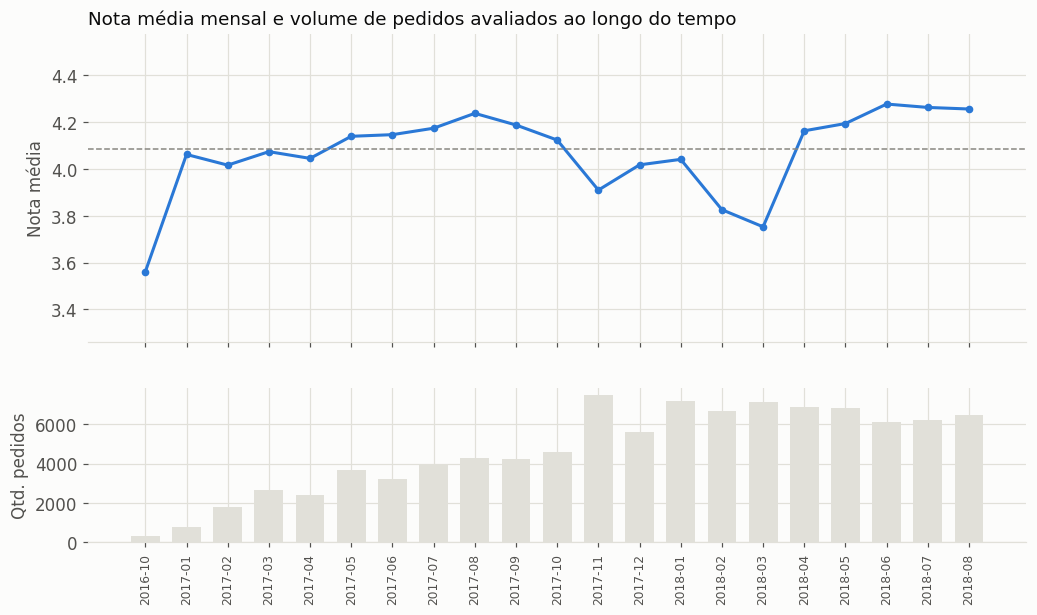

In [7]:
fato_pedidos['ano_mes'] = fato_pedidos['order_purchase_timestamp'].dt.to_period('M').astype(str)
mensal = fato_pedidos.groupby('ano_mes').agg(nota_media=('review_score', 'mean'), pedidos=('order_id', 'count'))
mensal = mensal[mensal['pedidos'] >= 50]  # remove meses de rampa (poucos pedidos, media instavel)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, height_ratios=[2, 1])

ax1.plot(mensal.index, mensal['nota_media'], color=CATEGORICO_ORDEM[0], linewidth=2, marker='o', markersize=4)
ax1.axhline(nota_media, color=TINTA_MUTED, linestyle='--', linewidth=1)
ax1.set_ylabel('Nota média')
ax1.set_title('Nota média mensal e volume de pedidos avaliados ao longo do tempo', loc='left', fontsize=12)
ax1.set_ylim(mensal['nota_media'].min() - 0.3, mensal['nota_media'].max() + 0.3)

ax2.bar(mensal.index, mensal['pedidos'], color=GRADE, width=0.7)
ax2.set_ylabel('Qtd. pedidos')
plt.setp(ax2.get_xticklabels(), rotation=90, fontsize=8)

salvar(fig, '06_tendencia_temporal.png')
plt.show()

**Achado:** a nota vem numa tendência geral de melhora, mas há um vale visível entre novembro/2017 e março/2018 — exatamente o período que inclui a Black Friday (novembro) e o pico de volume do gráfico de baixo. É consistente com a hipótese da seção 2: mais pedidos de uma vez tende a sobrecarregar a operação logística, gerar mais atrasos, e isso se reflete na satisfação nos meses seguintes.

## 7. Bônus: o que os clientes detratores estão dizendo

Até aqui usamos só a nota (1 a 5). Mas ~11 mil dos pedidos com nota de Detrator (1-2) também têm um comentário de texto escrito pelo cliente. Uma contagem simples de palavras mais frequentes nesses comentários serve como checagem: as palavras batem com os drivers que os números já apontaram?

> Duas limpezas feitas nos dados de texto antes de contar as palavras: (1) o texto original da Olist tem um problema de codificação de caracteres em parte dos comentários (ex.: "não" grava errado o acento) — corrigido revertendo a dupla-codificação palavra a palavra; (2) o dataset público substitui o nome da loja/marketplace por um apelido fictício ("lannister") como forma de anonimização — removido da contagem por não ser uma palavra real do cliente.

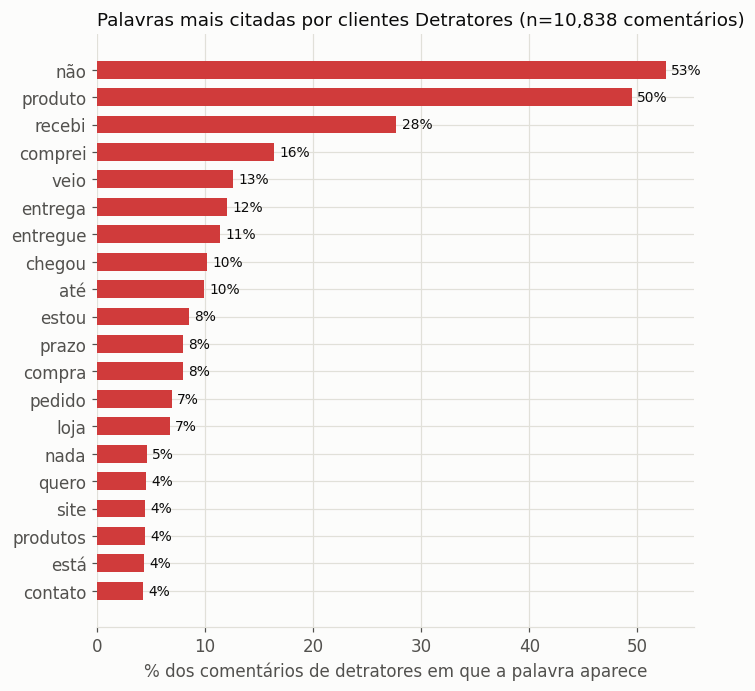

In [8]:
from text_utils import tokeniza

detratores_com_texto = fato_pedidos[
    (fato_pedidos['faixa_satisfacao'] == 'Detrator') & fato_pedidos['review_comment_message'].notna()
]

contador_palavras = Counter()
for msg in detratores_com_texto['review_comment_message']:
    contador_palavras.update(set(tokeniza(msg)))  # set() = 1 voto por comentário, não por ocorrência

top20 = pd.DataFrame(contador_palavras.most_common(20), columns=['palavra', 'qtd_comentarios'])
top20['pct_dos_comentarios'] = (top20['qtd_comentarios'] / len(detratores_com_texto) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(top20['palavra'][::-1], top20['pct_dos_comentarios'][::-1], color=COR_DETRATOR, height=0.65)
for i, v in enumerate(top20['pct_dos_comentarios'][::-1]):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=9)
ax.set_xlabel('% dos comentários de detratores em que a palavra aparece')
ax.set_title(f'Palavras mais citadas por clientes Detratores (n={len(detratores_com_texto):,} comentários)', loc='left', fontsize=12)
salvar(fig, '07_palavras_detratores.png')
plt.show()

**Achado:** as palavras mais citadas pelos detratores são quase todas sobre entrega — *recebi, comprei, veio, entrega, entregue, chegou, prazo, aguardando* — não sobre o produto em si. Isso bate exatamente com a seção 2: o problema número 1 não é "o que foi vendido", é "o pedido chegou?". `qualidade` aparece, mas bem mais abaixo — um driver secundário e real, só que menor.

## Conclusão: principais achados

1. **Prazo de entrega é, disparado, o maior driver de satisfação.** Nota média cai de 4,29 (no prazo) para 2,27 (atrasado), com efeito gradual — quanto mais atraso, pior a nota. Só 6,7% dos pedidos atrasam, mas o impacto por pedido é enorme.
2. **O texto dos detratores confirma o número:** as palavras mais citadas são sobre entrega, não sobre o produto.
3. **Móveis de escritório é a categoria com pior nota** (3,62) entre as com volume relevante; livros e alimentos ficam no topo.
4. **Região importa, provavelmente via o mesmo mecanismo de entrega:** os piores estados (RR, AL, MA) são justamente os mais distantes dos centros de distribuição.
5. **Forma de pagamento tem efeito pequeno**; mais parcelas está associado a nota um pouco menor.
6. **Novembro/2017–março/2018** (janela da Black Friday) mostra o pior trecho da série temporal — coerente com sobrecarga operacional afetando entrega.

**Implicação prática:** se a Olist quisesse melhorar a satisfação do cliente com uma única iniciativa, seria investir em previsibilidade de entrega (reduzir a cauda de atrasos), especialmente em picos de demanda e em regiões mais distantes — não em mudar o mix de produtos ou formas de pagamento.

Próximo passo: os mesmos dados viram um dashboard interativo em Streamlit (`dashboard/app.py`), para explorar esses cortes com filtros ao vivo.